# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shreya1111/flyrank-week1/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [9]:
import pandas as pd
import numpy as np

# Loading sample data for the assignment
path = '/content/sample_data/california_housing_train.csv'
df = pd.read_csv(path)
print(f"Dataset loaded with {len(df)} rows and {len(df.columns)} columns.")
df.head()

Dataset loaded with 17000 rows and 9 columns.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

In [10]:
# Verify unit of analysis: check for duplicates in what we assume is the grain
print(f"Total rows: {len(df)}")
print(f"Unique latitude/longitude pairs: {len(df.groupby(['latitude', 'longitude']))}")

Total rows: 17000
Unique latitude/longitude pairs: 11054


## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

In [11]:
# Inspect column types for categorization
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

In [12]:
# Check for missing values and basic stats
print("Missing values per column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Missing values per column:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

Basic Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

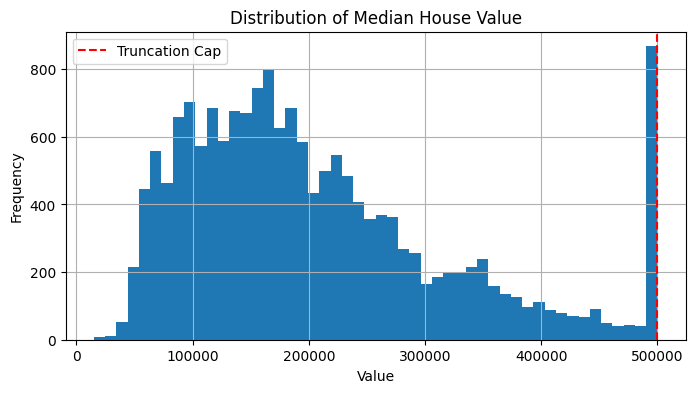

Number of records at the $500,001 cap: 814


In [13]:
import matplotlib.pyplot as plt

# Visualize the distribution to show the truncation at $500,001
plt.figure(figsize=(8, 4))
df['median_house_value'].hist(bins=50)
plt.title('Distribution of Median House Value')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.axvline(500001, color='red', linestyle='--', label='Truncation Cap')
plt.legend()
plt.show()

print(f"Number of records at the $500,001 cap: {(df['median_house_value'] >= 500001).sum()}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.